# Procesamiento Digital de Imágenes
## Guía de Trabajos Prácticos 8 — Morfología Matemática
**FICH, UNL — Ingeniería Informática**

## Ejercicio 1 Operaciones de erosion y dilatacion

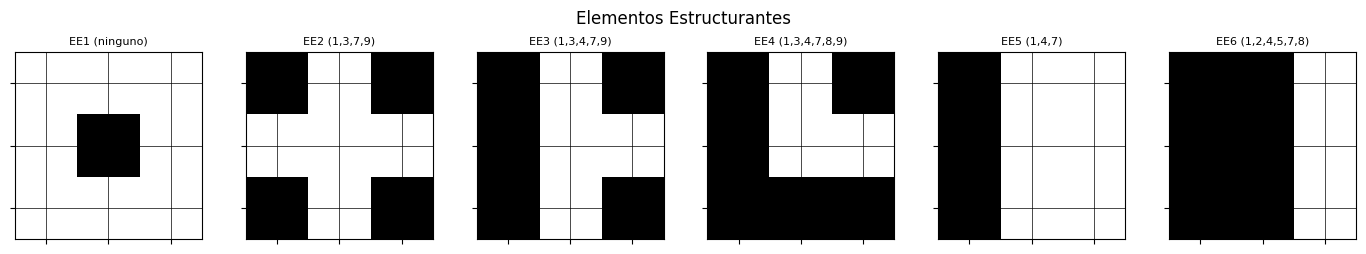

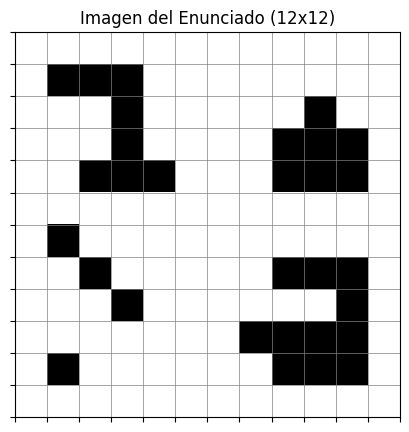

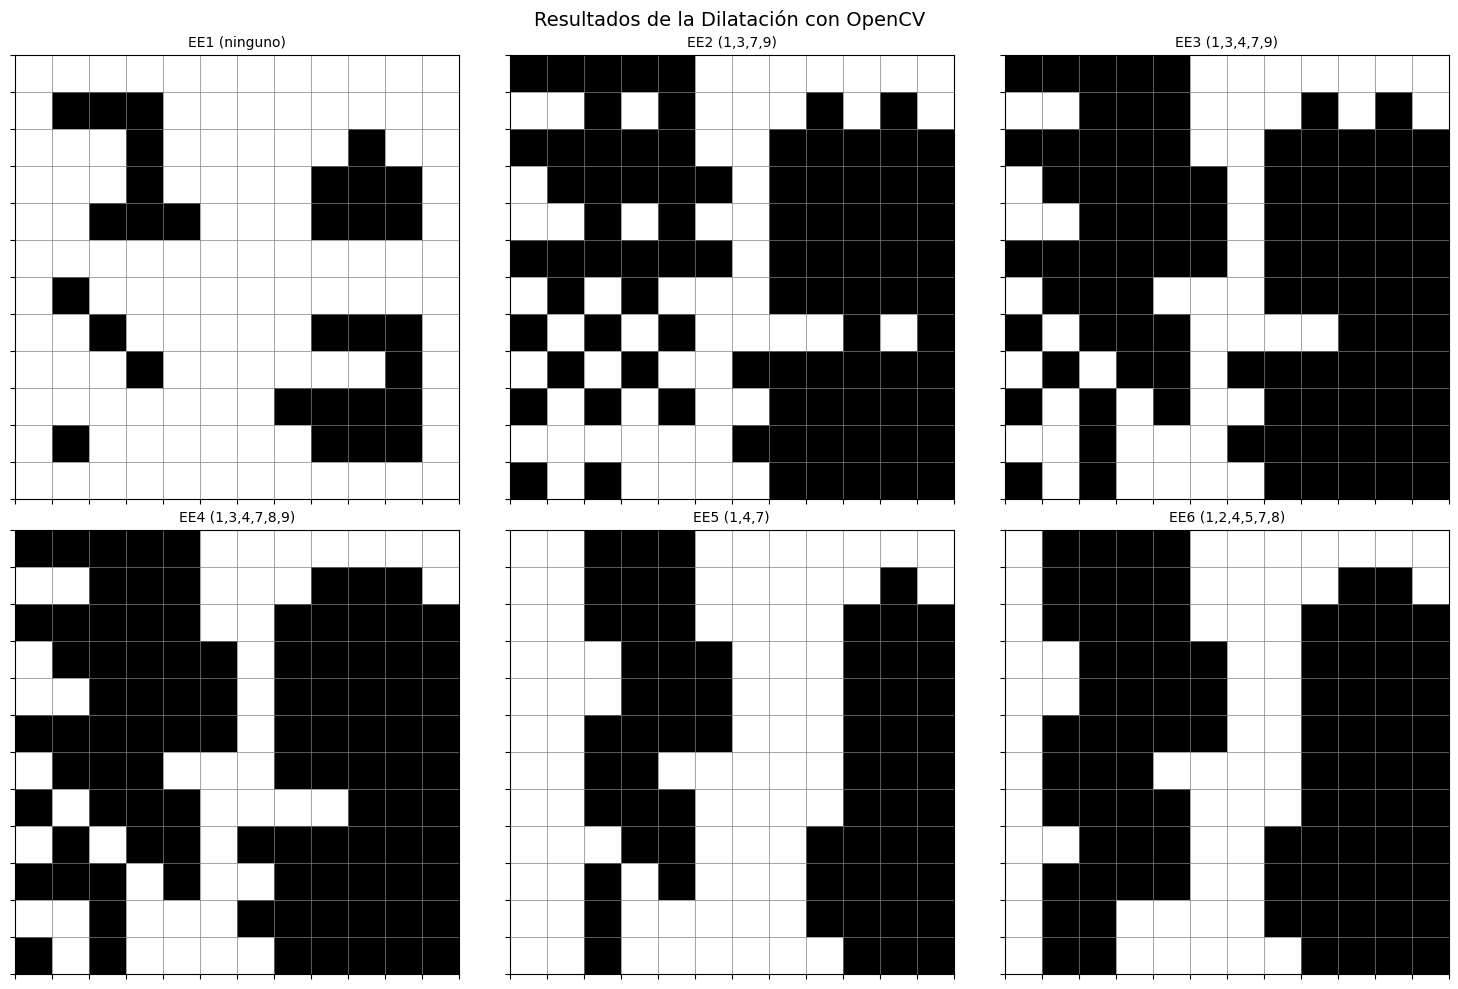

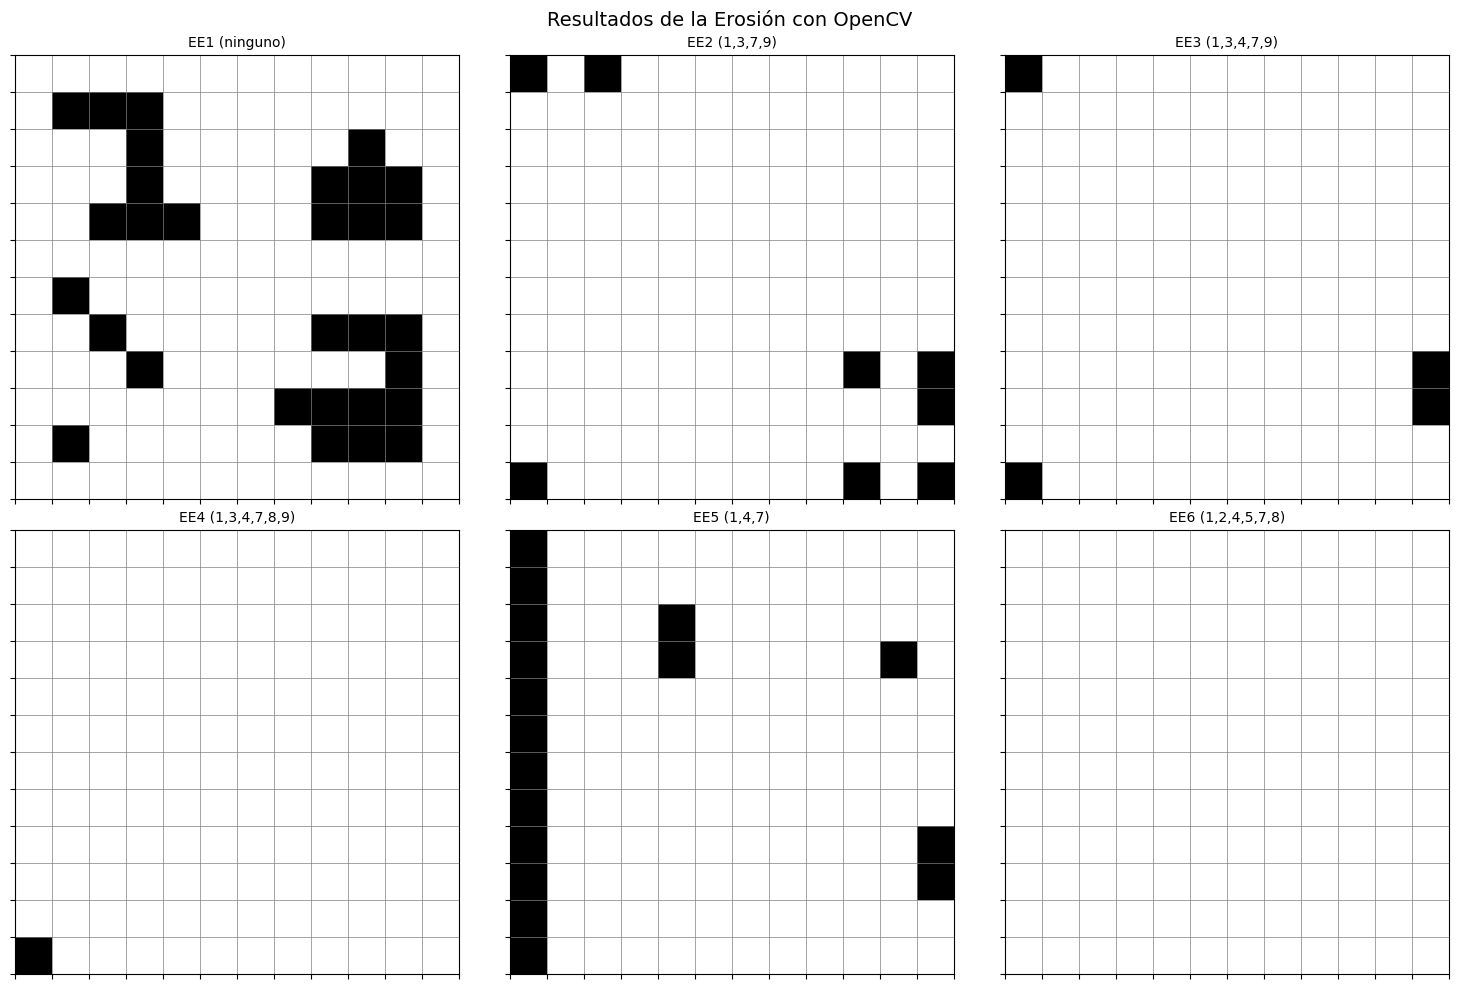

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ── Elementos Estructurantes ──────────────────────────────────────────────────
EE = {
    'EE1 (ninguno)':       np.array([[0,0,0],[0,1,0],[0,0,0]], np.uint8),  # solo centro = identidad real
    'EE2 (1,3,7,9)':       np.array([[1,0,1],[0,0,0],[1,0,1]], np.uint8),
    'EE3 (1,3,4,7,9)':     np.array([[1,0,1],[1,0,0],[1,0,1]], np.uint8),
    'EE4 (1,3,4,7,8,9)':   np.array([[1,0,1],[1,0,0],[1,1,1]], np.uint8),
    'EE5 (1,4,7)':         np.array([[1,0,0],[1,0,0],[1,0,0]], np.uint8),
    'EE6 (1,2,4,5,7,8)':   np.array([[1,1,0],[1,1,0],[1,1,0]], np.uint8),
}

EE2= np.array([[1,0,1],[0,0,0],[1,0,1]], np.uint8)
EE3= np.array([[1,0,1],[1,0,0],[1,0,1]], np.uint8)


# ── Visualización de EEs ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
for ax, (nombre, ee) in zip(axes, EE.items()):
    ax.imshow(ee, cmap='gray_r', vmin=0, vmax=1, interpolation='none')
    ax.set_title(nombre, fontsize=8)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.grid(True, color='black', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
plt.suptitle('Elementos Estructurantes', fontsize=12)
plt.tight_layout()
plt.show()

# ── Imagen del enunciado (objeto=1, fondo=0) ──────────────────────────────────
# CORREGIDO: objeto=1 (negro en gray_r), fondo=0 (blanco en gray_r)
img_ejercicio = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,0,1,0,0],
    [0,0,0,1,0,0,0,0,1,1,1,0],
    [0,0,1,1,1,0,0,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,0,1,1,1,0],
    [0,0,0,1,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,1,1,1,1,0],
    [0,1,0,0,0,0,0,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0]
], dtype=np.uint8)

# Convertir a uint8 con rango 0-255 para OpenCV
img_cv = (img_ejercicio * 255).astype(np.uint8)

# ── Visualización imagen original ─────────────────────────────────────────────
plt.figure(figsize=(5,5))
plt.imshow(img_ejercicio, cmap='gray_r', vmin=0, vmax=1, interpolation='none')
plt.grid(True, color='gray', linewidth=0.5)
plt.xticks(np.arange(-0.5, 12, 1), [])
plt.yticks(np.arange(-0.5, 12, 1), [])
plt.title("Imagen del Enunciado (12x12)")
plt.show()

# ── Dilatación ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (nombre, ee) in zip(axes.flatten(), EE.items()):
    dilatada_cv = cv2.dilate(img_cv, ee, iterations=1)
    # Volver a rango 0-1 para visualizar con gray_r
    dilatada = (dilatada_cv / 255).astype(np.uint8)

    ax.imshow(dilatada, cmap='gray_r', vmin=0, vmax=1, interpolation='none')
    ax.set_title(nombre, fontsize=10)
    ax.set_xticks(np.arange(-0.5, 12, 1))
    ax.set_yticks(np.arange(-0.5, 12, 1))
    ax.grid(True, color='gray', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
plt.suptitle('Resultados de la Dilatación con OpenCV', fontsize=14)
plt.tight_layout()
plt.show()

# ── Erosión ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (nombre, ee) in zip(axes.flatten(), EE.items()):
    erosionada_cv = cv2.erode(img_cv, ee, iterations=1)
    # Volver a rango 0-1 para visualizar con gray_r
    erosionada = (erosionada_cv / 255).astype(np.uint8)

    ax.imshow(erosionada, cmap='gray_r', vmin=0, vmax=1, interpolation='none')
    ax.set_title(nombre, fontsize=10)
    ax.set_xticks(np.arange(-0.5, 12, 1))
    ax.set_yticks(np.arange(-0.5, 12, 1))
    ax.grid(True, color='gray', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
plt.suptitle('Resultados de la Erosión con OpenCV', fontsize=14)
plt.tight_layout()
plt.show()

## Reflexión sobre Erosión y Dilatación

- **Dilatación**: expande las regiones de foreground. Un píxel se activa si *algún* vecino definido en el EE está activo.
- **Erosión**: contrae las regiones de foreground. Un píxel se mantiene activo solo si *todos* los vecinos del EE están activos.

## Ejercicio 2 Fosforos

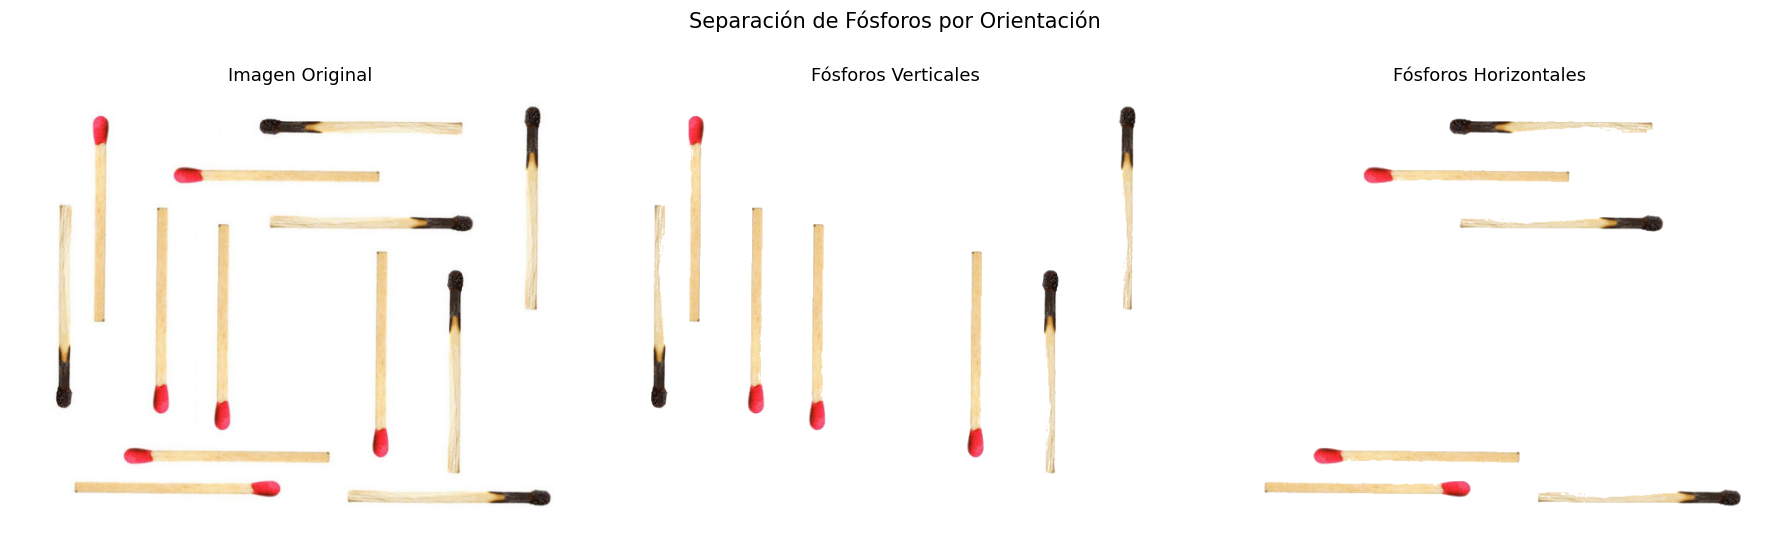

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ── 1. Cargar imagen ──────────────────────────────────────────────────────────
img = cv2.imread('fosforos.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ── 2. Binarizar ──────────────────────────────────────────────────────────────
_, binary = cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY_INV)

# ── 3. Elementos estructurantes direccionales ─────────────────────────────────
#2 píxeles de grosor para tolerar inclinaciones en los fósforos.
kernel_vertical   = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 40))
kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 2))

# ── 4. Morfología: apertura (Filtro por dirección) ────────────────────────────
mask_vertical   = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_vertical)
mask_horizontal = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_horizontal)

# ── 5. Recuperar la forma exacta del fósforo ──────────────────────────────────
kernel_expand = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))

# A. Dilatamos las líneas encontradas para que cubran el área del fósforo original
mask_vertical_exp   = cv2.dilate(mask_vertical, kernel_expand, iterations=2)
mask_horizontal_exp = cv2.dilate(mask_horizontal, kernel_expand, iterations=2)

# B. Hacemos un AND con la máscara binaria original para calcar los bordes exactos
mask_vertical_final = cv2.bitwise_and(binary, mask_vertical_exp)
mask_horizontal_final = cv2.bitwise_and(binary, mask_horizontal_exp)

# ── 6. Aplicar máscaras sobre imagen original ─────────────────────────────────
fondo_blanco = np.ones_like(img_rgb) * 255

result_vertical   = np.where(mask_vertical_final[:,:,None] > 0, img_rgb, fondo_blanco)
result_horizontal = np.where(mask_horizontal_final[:,:,None] > 0, img_rgb, fondo_blanco)

# ── 7. Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Imagen Original', fontsize=13)
axes[0].axis('off')

axes[1].imshow(result_vertical)
axes[1].set_title('Fósforos Verticales', fontsize=13)
axes[1].axis('off')

axes[2].imshow(result_horizontal)
axes[2].set_title('Fósforos Horizontales', fontsize=13)
axes[2].axis('off')

plt.suptitle('Separación de Fósforos por Orientación', fontsize=15)
plt.tight_layout()
plt.show()

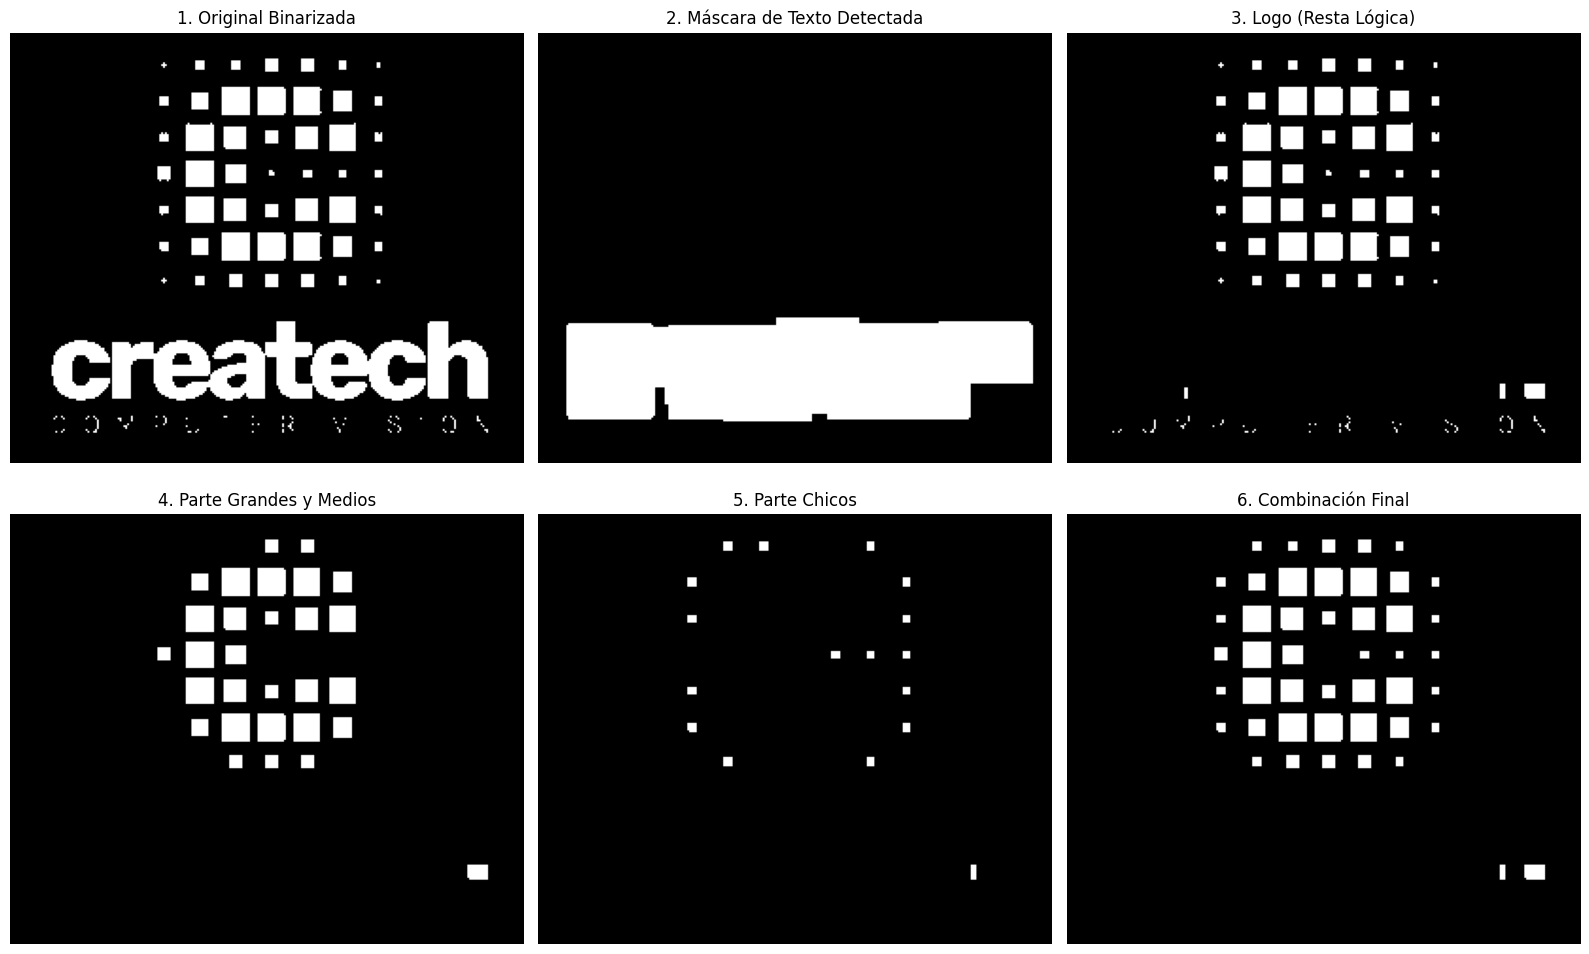

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Cargar y Binarizar ──────────────────────────────────────────────────────
img = cv2.imread('createch01.png', cv2.IMREAD_GRAYSCALE)

# Binarización Invertida: Queremos el logo en blanco (255) y el fondo negro (0)
_, binaria = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)


# ── 2. Eliminación Automática del texto ────────────────
# Las letras del logo tienen lineas continuas y el logo solo cuadros separados
# Buscamos estructuras horizontales muy largas probando con x pixeles
kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))

# Apertura: Aisla los trazos horizontales del texto 
trazos_texto = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel_horizontal)

# Dilatamos esos trazos para crear un "bloque" sólido que cubra todas las palabras enteras
kernel_expansion = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 30))
mascara_texto = cv2.dilate(trazos_texto, kernel_expansion)

# Operación Lógica resta: borramos el texto
logo_aislado = cv2.bitwise_and(binaria, cv2.bitwise_not(mascara_texto))

# ── 3. Extraer por partes y combinar  ──────────────────────
#3 Elementos Estructurantes de distintos tamaños
k_grande = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
k_medio  = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
k_chico  = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Parte A: Solo los cuadrados GRANDES
parte_grande = cv2.morphologyEx(logo_aislado, cv2.MORPH_OPEN, k_grande)

# Parte B: Solo los cuadrados MEDIANOS (Extraemos los medios y le restamos los grandes)
apertura_medio = cv2.morphologyEx(logo_aislado, cv2.MORPH_OPEN, k_medio)
parte_media = cv2.subtract(apertura_medio, parte_grande)

# Parte C: Solo los cuadrados CHICOS (Extraemos los chicos y le restamos los medios)
apertura_chico = cv2.morphologyEx(logo_aislado, cv2.MORPH_OPEN, k_chico)
parte_chica = cv2.subtract(apertura_chico, apertura_medio)

# COMBINACIÓN FINAL: OR con las tres partes
logo_final = cv2.bitwise_or(parte_grande, cv2.bitwise_or(parte_media, parte_chica))


# ── 4. Visualización del Proceso ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
ax = axes.flatten()

titulos = ['1. Original Binarizada', '2. Máscara de Texto Detectada', '3. Logo (Resta Lógica)', 
           '4. Parte Grandes y Medios', '5. Parte Chicos', '6. Combinación Final']
imagenes = [binaria, mascara_texto, logo_aislado, 
            cv2.bitwise_or(parte_grande, parte_media), parte_chica, logo_final]

for i in range(6):
    ax[i].imshow(imagenes[i], cmap='gray')
    ax[i].set_title(titulos[i], fontsize=12)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

## Ejercicio 2 Operaciones de apertura y cierre

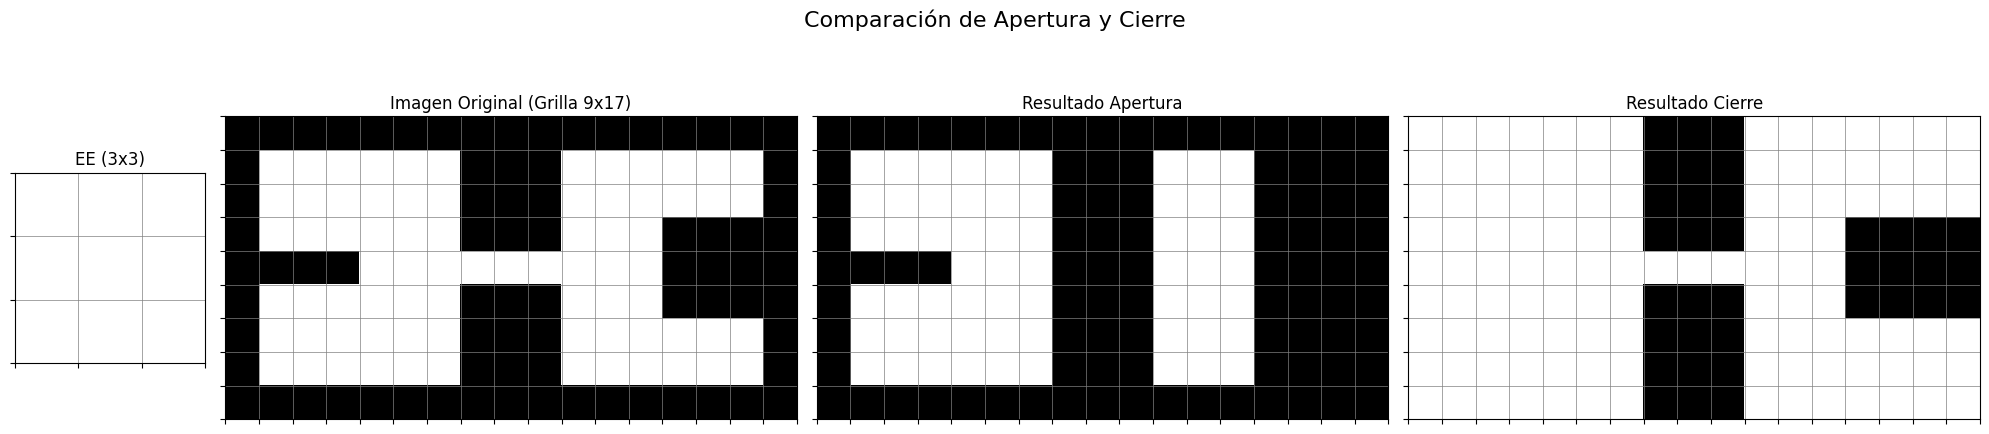

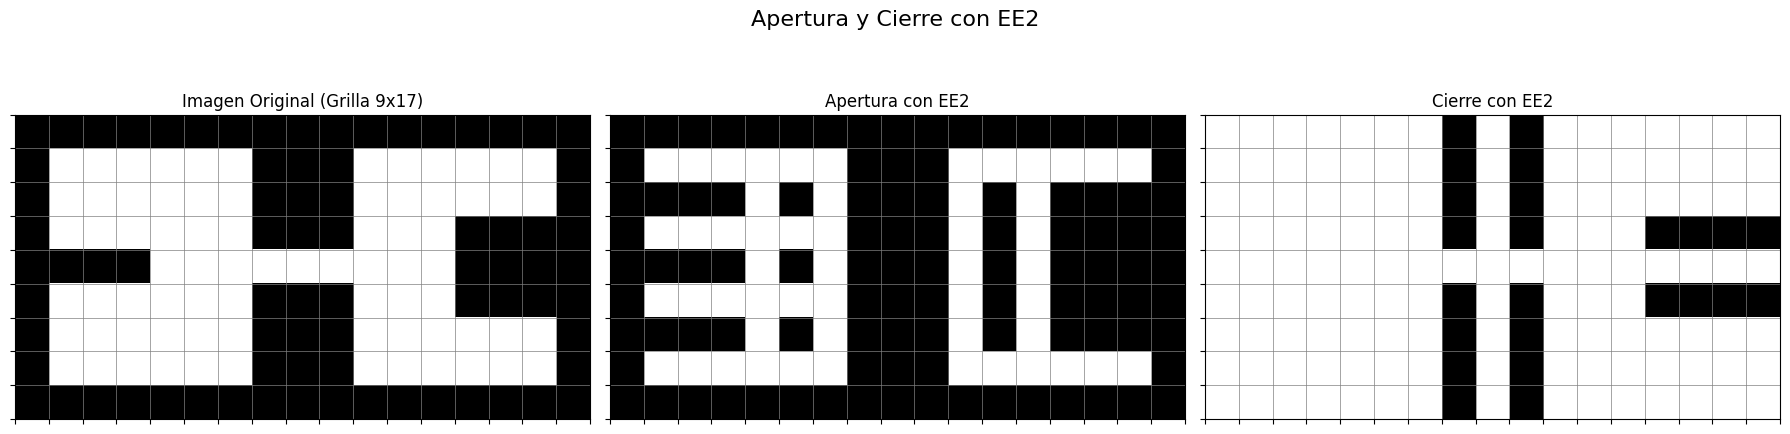

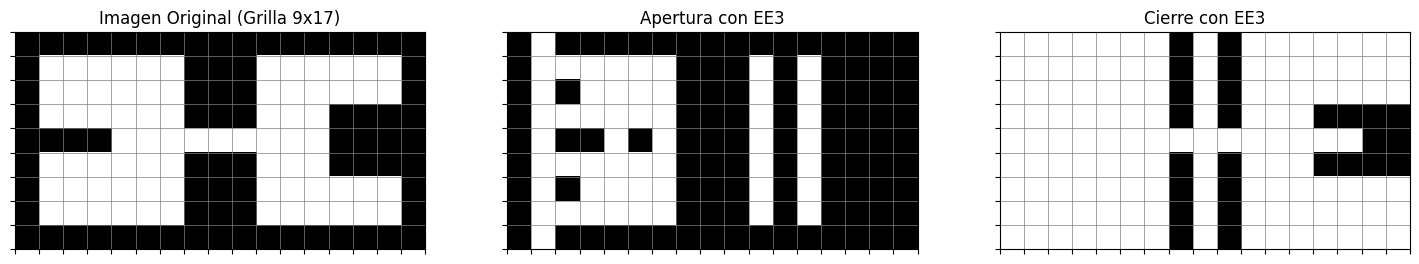

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de la Imagen y el Elemento Estructurante
# ── Generar Imagen Original (representación de la grilla 9x17) ──────────────────
img_orig_raw = np.array([
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1],
    [1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1],
    [1,0,0,0,0,0,0,1,1,1,0,0,0,1,1,1,1],
    [1,1,1,1,0,0,0,0,0,0,0,0,0,1,1,1,1],
    [1,0,0,0,0,0,0,1,1,1,0,0,0,1,1,1,1],
    [1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1],
    [1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
], dtype=np.uint8)

# Inversión para procesamiento
img_processing = (1 - img_orig_raw) * 255

# ── Generar Elemento Estructurante (EE) ──────────────────────────────────────────
# El enunciado muestra un cuadrado 3x3 completo, usamos MORPH_RECT
kernel_3x3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# 2. Procesamiento Morfológico
apertura = cv2.morphologyEx(img_processing, cv2.MORPH_OPEN, kernel_3x3)
cierre   = cv2.morphologyEx(img_processing, cv2.MORPH_CLOSE, kernel_3x3)

apertura2 = cv2.morphologyEx(img_processing, cv2.MORPH_OPEN, EE2)
cierre2   = cv2.morphologyEx(img_processing, cv2.MORPH_CLOSE, EE2)
apertura3= cv2.morphologyEx(img_processing, cv2.MORPH_OPEN, EE3)
cierre3= cv2.morphologyEx(img_processing, cv2.MORPH_CLOSE, EE3)

# 3. Visualización y Comparación
fig, axes = plt.subplots(1, 4, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 3, 3, 3]})

# ── Graficar el Elemento Estructurante (EE) ──
axes[0].imshow(kernel_3x3, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('EE (3x3)', fontsize=12)
axes[0].set_xticks(np.arange(-0.5, 3, 1))
axes[0].set_yticks(np.arange(-0.5, 3, 1))
axes[0].grid(True, color='gray', linewidth=0.5)
axes[0].set_xticklabels([])
axes[0].set_yticklabels([])

# ── Graficar Imagen, Apertura y Cierre ──
titles = ['Imagen Original (Grilla 9x17)', 
          'Resultado Apertura', 
          'Resultado Cierre']
images = [img_processing, apertura, cierre]

for i in range(3):
    ax = axes[i+1] 
    ax.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(titles[i], fontsize=12)
    ax.set_xticks(np.arange(-0.5, 17, 1))
    ax.set_yticks(np.arange(-0.5, 9, 1))
    ax.grid(True, color='gray', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.suptitle('Comparación de Apertura y Cierre', fontsize=16)
plt.tight_layout()
plt.show()

# ── Graficar Imagen, Apertura y Cierre 2 y 3 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Imagen Original (Grilla 9x17)', 
          'Apertura con EE2', 
          'Cierre con EE2']
images = [img_processing, apertura2, cierre2]
for i in range(3):
    ax = axes[i] 
    ax.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(titles[i], fontsize=12)
    ax.set_xticks(np.arange(-0.5, 17, 1))
    ax.set_yticks(np.arange(-0.5, 9, 1))
    ax.grid(True, color='gray', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
plt.suptitle('Apertura y Cierre con EE2', fontsize=16)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Imagen Original (Grilla 9x17)',
            'Apertura con EE3', 
            'Cierre con EE3']
images = [img_processing, apertura3, cierre3]
for i in range(3):
    ax = axes[i] 
    ax.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(titles[i], fontsize=12)
    ax.set_xticks(np.arange(-0.5, 17, 1))
    ax.set_yticks(np.arange(-0.5, 9, 1))
    ax.grid(True, color='gray', linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

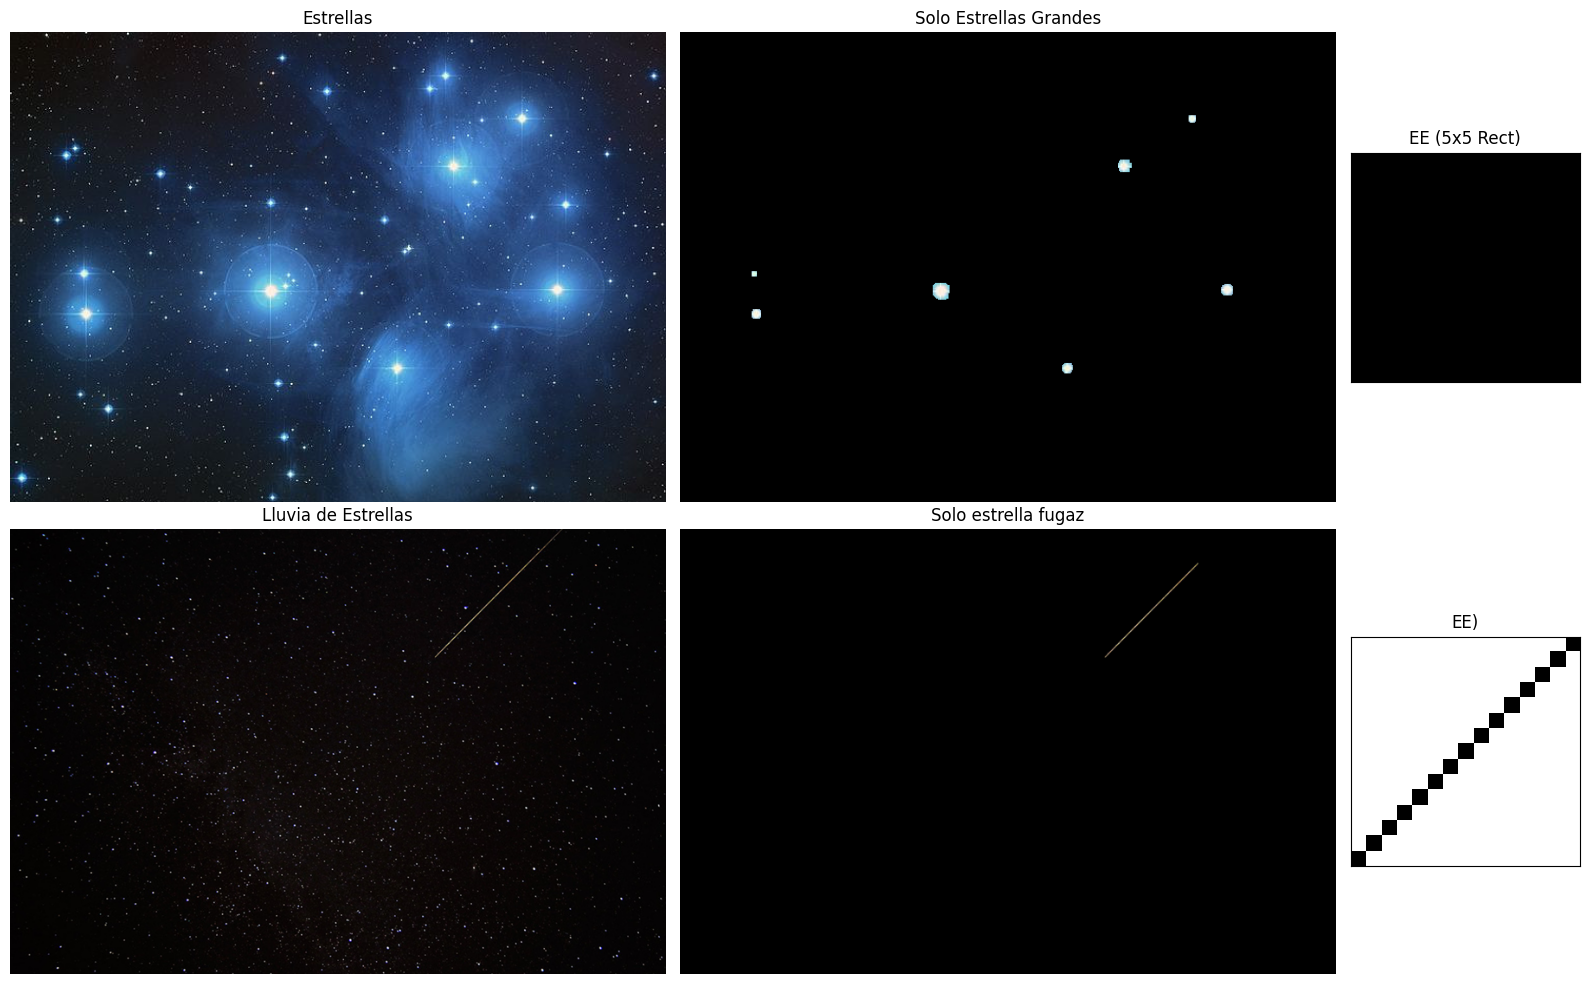

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def cargar_imagen(nombre_base):
    # Intenta cargar PNG, si falla intenta JPG
    img = cv2.imread(f"{nombre_base}.png")
    if img is None:
        img = cv2.imread(f"{nombre_base}.jpg")
    return img

# ─Extraer solo las estrellas grandes──────────
img_stars_color = cargar_imagen('estrellas')

if img_stars_color is None:
    print("🚨 Error: No se encontró estrellas.png o estrellas.jpg.")
else:
    img_stars_color = cv2.cvtColor(img_stars_color, cv2.COLOR_BGR2RGB)
    img_stars_gray = cv2.cvtColor(img_stars_color, cv2.COLOR_RGB2GRAY)
    
    _, binary_stars = cv2.threshold(img_stars_gray, 180, 255, cv2.THRESH_BINARY)

    # EE Cuadrado de 5x5
    ee_stars_grandes = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

    # Apertura
    estrellas_grandes_mask = cv2.morphologyEx(binary_stars, cv2.MORPH_OPEN, ee_stars_grandes)

    fondo_negro_stars = np.zeros_like(img_stars_color)
    resultado_stars = np.where(estrellas_grandes_mask[:,:,None] > 0, img_stars_color, fondo_negro_stars)


# ──Extraer la estrella fugaz ──────────────
img_rain_color = cargar_imagen('lluviaEstrellas')

if img_rain_color is None:
    print("error no se encontro")
else:
    img_rain_color = cv2.cvtColor(img_rain_color, cv2.COLOR_BGR2RGB)
    img_rain_gray = cv2.cvtColor(img_rain_color, cv2.COLOR_RGB2GRAY)
    
    _, binary_rain = cv2.threshold(img_rain_gray, 100, 255, cv2.THRESH_BINARY)

    size_line = 15
    ee_fugaz = np.fliplr(np.eye(size_line, dtype=np.uint8)) 

    # Apertura
    fugaz_mask = cv2.morphologyEx(binary_rain, cv2.MORPH_OPEN, ee_fugaz)
    
    # dilatación extra para que la línea se vea mejor en el gráfico final
    fugaz_mask = cv2.dilate(fugaz_mask, np.ones((3,3), np.uint8), iterations=1)

    fondo_negro_rain = np.zeros_like(img_rain_color)
    resultado_rain = np.where(fugaz_mask[:,:,None] > 0, img_rain_color, fondo_negro_rain)


# ── 3. Visualización Completa ──────────────────────────────────────────────────
if img_stars_color is not None and img_rain_color is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), gridspec_kw={'width_ratios': [2, 2, 0.7]}) 

    # Fila 1: Estrellas Grandes
    axes[0, 0].imshow(img_stars_color); axes[0, 0].set_title('Estrellas'); axes[0, 0].axis('off')
    axes[0, 1].imshow(resultado_stars); axes[0, 1].set_title('Solo Estrellas Grandes'); axes[0, 1].axis('off')
    axes[0, 2].imshow(ee_stars_grandes, cmap='gray_r', vmin=0, vmax=1); axes[0, 2].set_title('EE (5x5 Rect)')
    axes[0, 2].set_xticks([]); axes[0, 2].set_yticks([]); axes[0, 2].grid(True, color='gray')

    # Fila 2: Estrella Fugaz
    axes[1, 0].imshow(img_rain_color); axes[1, 0].set_title('Lluvia de Estrellas'); axes[1, 0].axis('off')
    axes[1, 1].imshow(resultado_rain); axes[1, 1].set_title('Solo estrella fugaz'); axes[1, 1].axis('off')
    
    # Mostrar el EE corregido (/)
    axes[1, 2].imshow(ee_fugaz, cmap='gray_r', vmin=0, vmax=1); axes[1, 2].set_title('EE)')
    axes[1, 2].set_xticks([]); axes[1, 2].set_yticks([]); axes[1, 2].grid(True, color='gray')

    plt.tight_layout()
    plt.show()

## Ejercicio 3 Gradiente morfologico

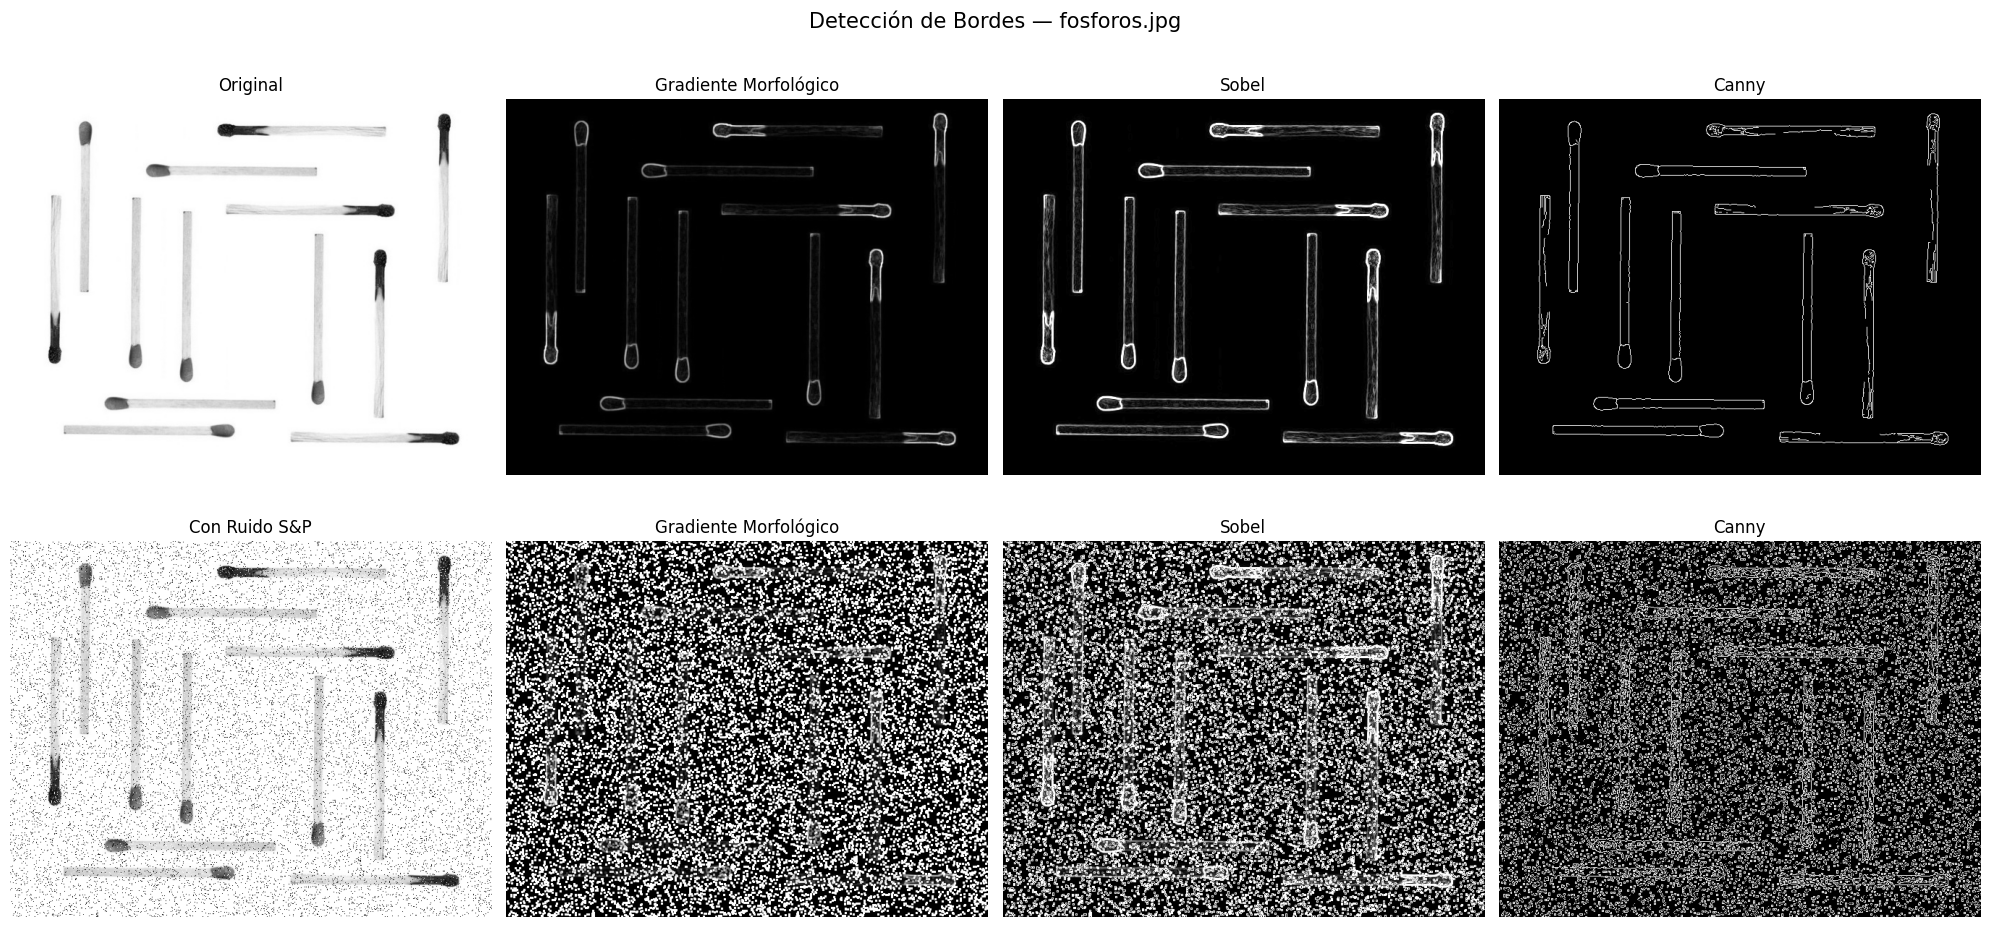

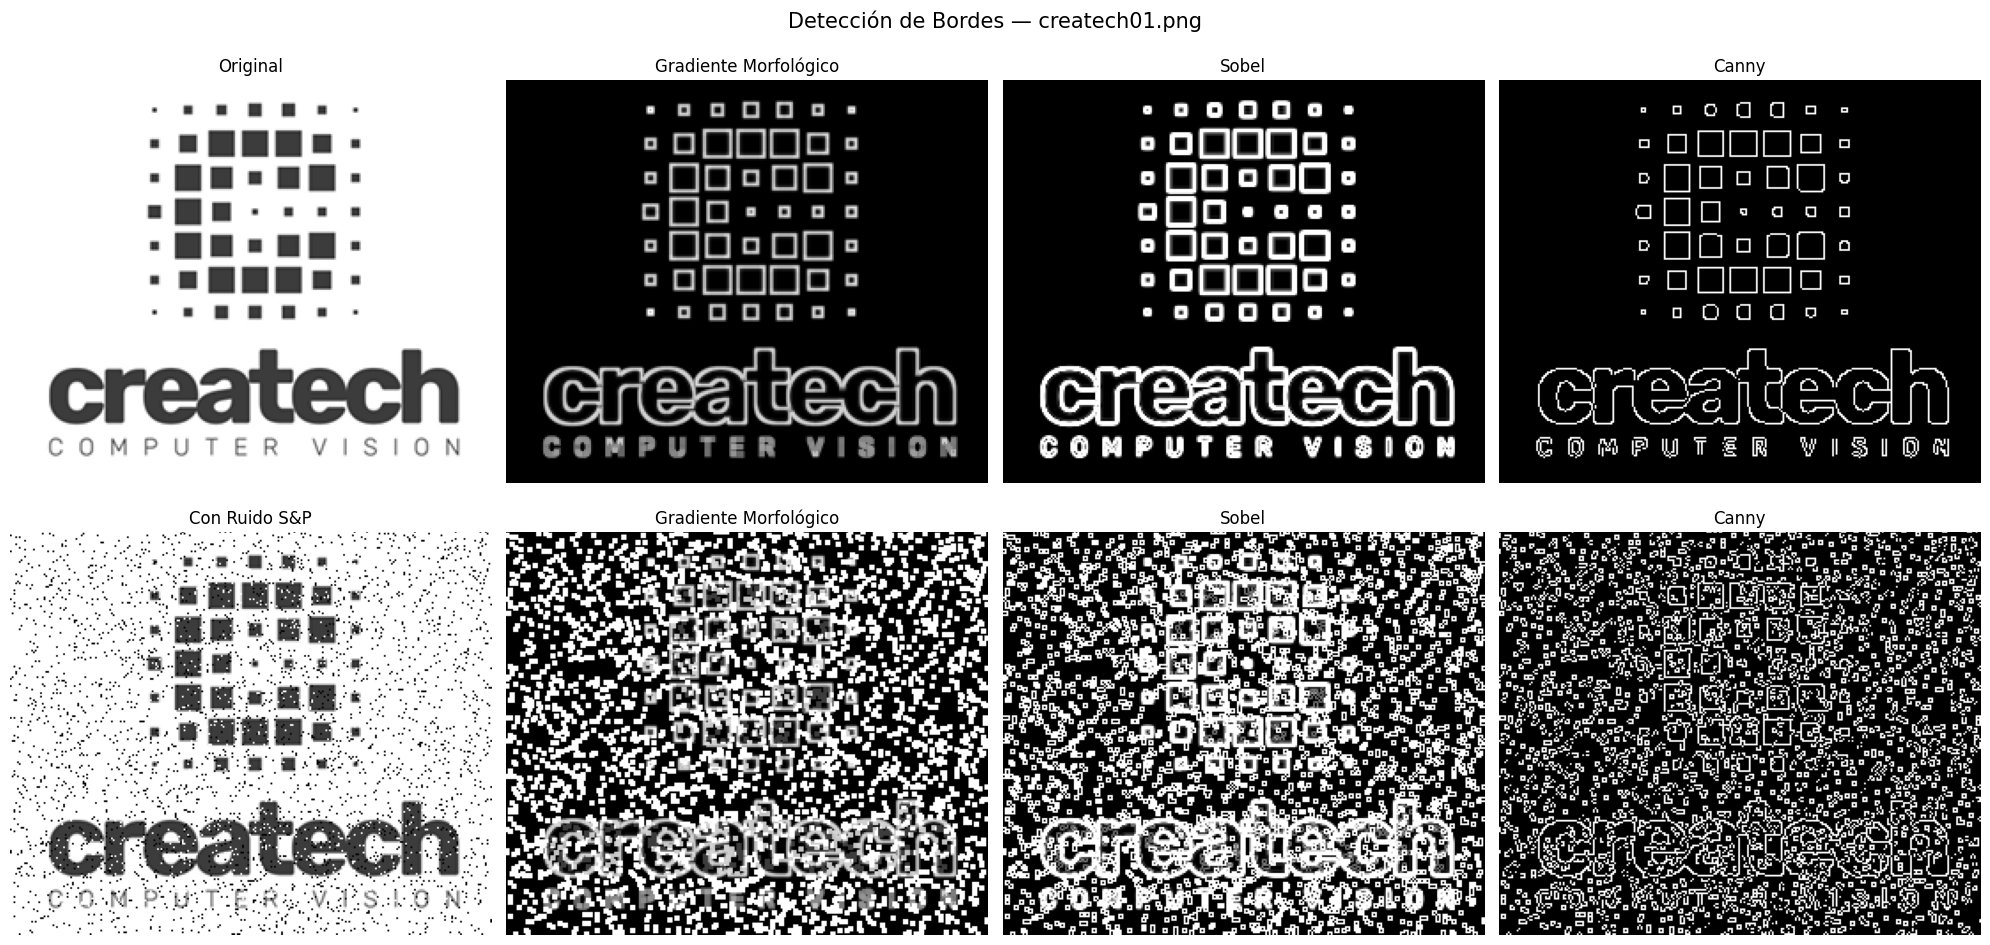

In [28]:
# ════════════════════════════════════════════════════════════════════════════════
# FUNCIONES AUXILIARES
# ════════════════════════════════════════════════════════════════════════════════

def agregar_sal_pimienta(img_gray, cantidad=0.05):
    """Agrega ruido sal y pimienta a una imagen en escala de grises."""
    ruidosa = img_gray.copy()
    n_pixeles = int(cantidad * img_gray.size)
    # Sal (blanco)
    coords = [np.random.randint(0, i, n_pixeles) for i in img_gray.shape]
    ruidosa[coords[0], coords[1]] = 255
    # Pimienta (negro)
    coords = [np.random.randint(0, i, n_pixeles) for i in img_gray.shape]
    ruidosa[coords[0], coords[1]] = 0
    return ruidosa

def aplicar_metodos(img_gray, titulo):
    """Aplica gradiente morfológico, Sobel y Canny. Retorna las 3 imágenes."""
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

    # 1. Gradiente morfológico = dilatación - erosión
    gradiente = cv2.morphologyEx(img_gray, cv2.MORPH_GRADIENT, kernel)

    # 2. Sobel (combinando X e Y)
    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel   = cv2.convertScaleAbs(np.sqrt(sobel_x**2 + sobel_y**2))

    # 3. Canny
    canny = cv2.Canny(img_gray, 50, 150)

    return gradiente, sobel, canny

def mostrar_comparacion(img_orig, img_ruidosa, titulo):
    """Muestra una grilla 2x4 comparando original vs ruidosa para los 3 métodos."""
    grad_orig,  sobel_orig,  canny_orig  = aplicar_metodos(img_orig,    titulo)
    grad_ruid,  sobel_ruid,  canny_ruid  = aplicar_metodos(img_ruidosa, titulo)

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f'Detección de Bordes — {titulo}', fontsize=15)

    # Fila 1: imagen original
    axes[0,0].imshow(img_orig,    cmap='gray'); axes[0,0].set_title('Original')
    axes[0,1].imshow(grad_orig,   cmap='gray'); axes[0,1].set_title('Gradiente Morfológico')
    axes[0,2].imshow(sobel_orig,  cmap='gray'); axes[0,2].set_title('Sobel')
    axes[0,3].imshow(canny_orig,  cmap='gray'); axes[0,3].set_title('Canny')

    # Fila 2: imagen con ruido
    axes[1,0].imshow(img_ruidosa, cmap='gray'); axes[1,0].set_title('Con Ruido S&P')
    axes[1,1].imshow(grad_ruid,   cmap='gray'); axes[1,1].set_title('Gradiente Morfológico')
    axes[1,2].imshow(sobel_ruid,  cmap='gray'); axes[1,2].set_title('Sobel')
    axes[1,3].imshow(canny_ruid,  cmap='gray'); axes[1,3].set_title('Canny')

    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# ════════════════════════════════════════════════════════════════════════════════
# IMAGEN 1: fosforos.jpg
# ════════════════════════════════════════════════════════════════════════════════
fosforos     = cv2.imread('fosforos.jpg')
fosforos_g   = cv2.cvtColor(fosforos, cv2.COLOR_BGR2GRAY)
fosforos_ruid = agregar_sal_pimienta(fosforos_g, cantidad=0.05)

mostrar_comparacion(fosforos_g, fosforos_ruid, 'fosforos.jpg')

# ════════════════════════════════════════════════════════════════════════════════
# IMAGEN 2: createch01.png
# ════════════════════════════════════════════════════════════════════════════════
createch     = cv2.imread('createch01.png')
createch_g   = cv2.cvtColor(createch, cv2.COLOR_BGR2GRAY)
createch_ruid = agregar_sal_pimienta(createch_g, cantidad=0.05)

mostrar_comparacion(createch_g, createch_ruid, 'createch01.png')

## Ejercicio 4 Operaciones de Hit-or-Miss y reconstruccion por dilatacion

🎯 Píxeles Hit encontrados para la 'T': 8


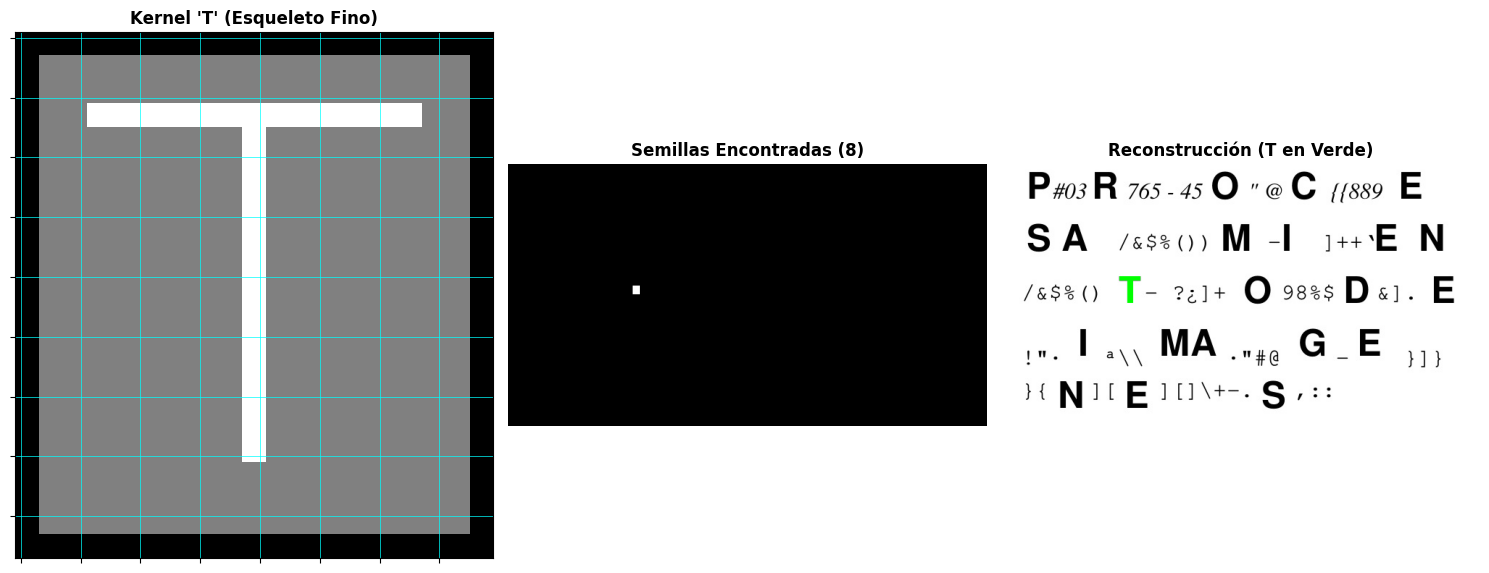

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def paso1_encontrar_T_esqueleto(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("🚨 Error al cargar imagen")
        return

    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # ==========================================================================
    # DISEÑO DEL MOLDE "ESQUELETO" (Basado en tus medidas 38x34)
    # ==========================================================================
    # Creamos un bloque un poco más grande que la letra (44 de alto x 40 de ancho)
    ee_T = np.full((44, 40), -1, dtype=np.int8)
    
    # COLCHÓN GIGANTE: Dejamos solo un marquito de 2 píxeles de -1, el resto todo 0
    ee_T[2:-2, 2:-2] = 0
    
    # ESQUELETO ULTRA FINO (1 o 2 píxeles de grosor para que encaje sí o sí)
    # Techo de la T: Fila 6 y 7. Columnas de la 6 a la 34.
    ee_T[6:8, 6:34] = 1 
    
    # Palo central de la T: Baja desde la fila 8 hasta la 36. Columnas 19 y 20 (bien al centro)
    ee_T[8:36, 19:21] = 1

    # Aplicamos Hit-or-Miss
    hit_T = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, ee_T)
    
    # Contamos cuántos píxeles exactos hicieron "Hit"
    hits_totales = np.count_nonzero(hit_T)
    print(f"🎯 Píxeles Hit encontrados para la 'T': {hits_totales}")

    # ==========================================================================
    # RECONSTRUCCIÓN
    # ==========================================================================
    def reconstruir(marcador, mascara):
        if np.count_nonzero(marcador) == 0: return np.zeros_like(mascara)
        kernel = np.ones((3,3), np.uint8)
        marcador_prev = np.zeros_like(marcador)
        marcador_curr = marcador.copy()
        while not np.array_equal(marcador_curr, marcador_prev):
            marcador_prev = marcador_curr.copy()
            dilatado = cv2.dilate(marcador_curr, kernel)
            marcador_curr = cv2.bitwise_and(dilatado, mascara)
        return marcador_curr

    rec_T = reconstruir(hit_T, binary)

    img_color = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2RGB)
    img_color[rec_T == 255] = [0, 255, 0]

    # ==========================================================================
    # VISUALIZACIÓN
    # ==========================================================================
    fig = plt.figure(figsize=(15, 6))
    gs = fig.add_gridspec(1, 3)

    # 1. Ver el Kernel
    ax_k = fig.add_subplot(gs[0, 0])
    ax_k.imshow(ee_T, cmap='gray', vmin=-1, vmax=1)
    ax_k.set_title("Kernel 'T' (Esqueleto Fino)", fontweight='bold')
    ax_k.grid(True, color='cyan', linestyle='-', linewidth=0.5)
    ax_k.set_xticklabels([]); ax_k.set_yticklabels([])

    # 2. Semillas Encontradas
    ax_hits = fig.add_subplot(gs[0, 1])
    # Dilatamos mucho el punto para que se vea en el gráfico
    hits_visibles = cv2.dilate(hit_T, np.ones((9,9), np.uint8))
    ax_hits.imshow(hits_visibles, cmap='gray')
    ax_hits.set_title(f"Semillas Encontradas ({hits_totales})", fontweight='bold')
    ax_hits.axis('off')

    # 3. Resultado Final
    ax_res = fig.add_subplot(gs[0, 2])
    ax_res.imshow(img_color)
    ax_res.set_title("Reconstrucción (T en Verde)", fontweight='bold')
    ax_res.axis('off')

    plt.tight_layout()
    plt.show()

paso1_encontrar_T_esqueleto("Caracteres.jpg")

Hits 'E': 30
Hits 'T': 8
Hits 'I': 48


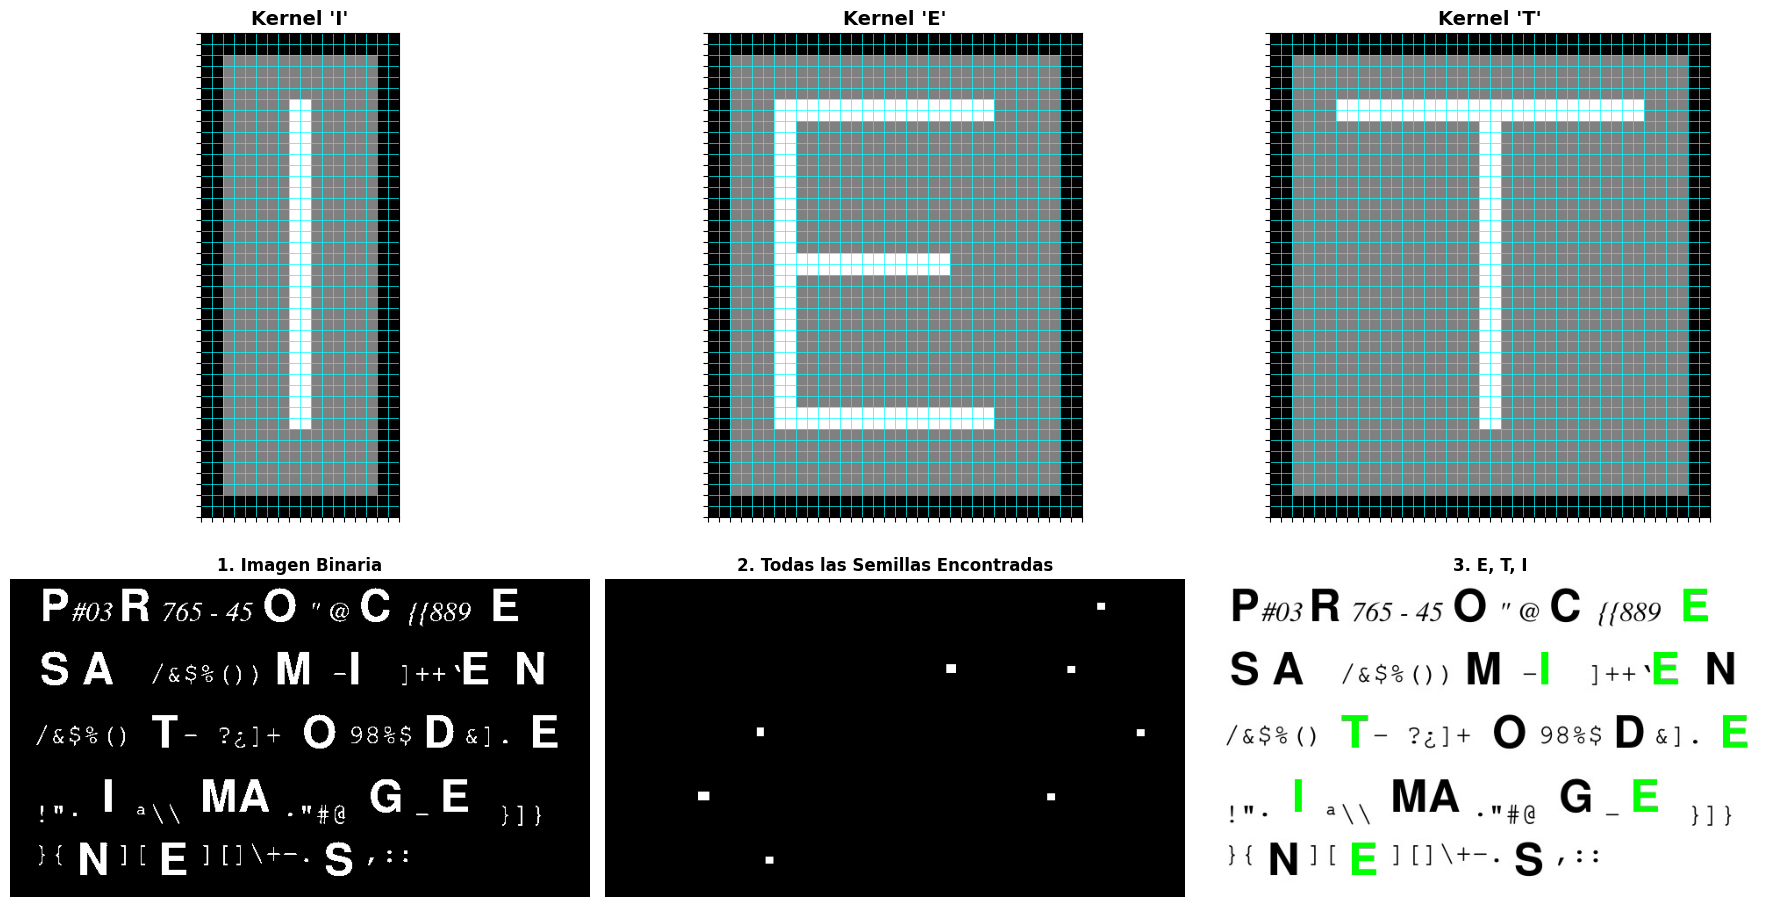

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def hit_or_miss(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error al cargar imagen")
        return

    # Binarización
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # DISEÑO DE LOS 3 KERNELS
    
    # 1. KERNEL T
    ee_T = np.full((44, 40), -1, dtype=np.int8)
    ee_T[2:-2, 2:-2] = 0
    ee_T[6:8, 6:34] = 1 
    ee_T[8:36, 19:21] = 1

    # 2. KERNEL 'E'
    ee_E = np.full((44, 34), -1, dtype=np.int8)
    ee_E[2:-2, 2:-2] = 0
    ee_E[6:36, 6:8] = 1     # Palo vertical izquierdo
    ee_E[6:8, 8:26] = 1     # Palo horizontal superior
    ee_E[20:22, 8:22] = 1   # Palo horizontal medio (un poco más corto)
    ee_E[34:36, 8:26] = 1   # Palo horizontal inferior

    # 3. KERNEL 'I'
    ee_I = np.full((44, 18), -1, dtype=np.int8)
    ee_I[2:-2, 2:-2] = 0
    ee_I[6:36, 8:10] = 1   

    # ════════════════════════════════════════════════════════════════════════════════
    # EJECUCIÓN DEL HIT-OR-MISS
    # ════════════════════════════════════════════════════════════════════════════════
    hit_E = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, ee_E)
    hit_T = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, ee_T)
    hit_I = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, ee_I)

    # Imprimimos los aciertos
    print(f"Hits 'E': {np.count_nonzero(hit_E)}")
    print(f"Hits 'T': {np.count_nonzero(hit_T)}")
    print(f"Hits 'I': {np.count_nonzero(hit_I)}")

    # ════════════════════════════════════════════════════════════════════════════════
    # RECONSTRUCCIÓN GEODÉSICA
    # ════════════════════════════════════════════════════════════════════════════════
    def reconstruir(marcador, mascara):
        if np.count_nonzero(marcador) == 0: return np.zeros_like(mascara)
        kernel = np.ones((3,3), np.uint8)
        marcador_prev = np.zeros_like(marcador)
        marcador_curr = marcador.copy()
        while not np.array_equal(marcador_curr, marcador_prev):
            marcador_prev = marcador_curr.copy()
            dilatado = cv2.dilate(marcador_curr, kernel)
            marcador_curr = cv2.bitwise_and(dilatado, mascara)
        return marcador_curr

    rec_E = reconstruir(hit_E, binary)
    rec_T = reconstruir(hit_T, binary)
    rec_I = reconstruir(hit_I, binary)

    # Combinamos todas las reconstrucciones
    reconstruccion_total = cv2.bitwise_or(rec_I, cv2.bitwise_or(rec_E, rec_T))

    # Pintamos de verde sobre la original
    img_color = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2RGB)
    img_color[reconstruccion_total == 255] = [0, 255, 0]


    # GRÁFICOS FINALES
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3)

    # Fila 1: Los 3 Kernels
    kernels = [ee_I, ee_E, ee_T]
    titulos = ["Kernel 'I'", "Kernel 'E'", "Kernel 'T'"]
    for i in range(3):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(kernels[i], cmap='gray', vmin=-1, vmax=1)
        ax.set_title(titulos[i], fontsize=14, fontweight='bold')
        ax.set_xticks(np.arange(-0.5, kernels[i].shape[1], 1))
        ax.set_yticks(np.arange(-0.5, kernels[i].shape[0], 1))
        ax.grid(True, color='cyan', linestyle='-', linewidth=0.5)
        ax.set_xticklabels([]); ax_yticklabels = ax.set_yticklabels([])

    # Fila 2: El proceso en la imagen
    ax_bin = fig.add_subplot(gs[1, 0])
    ax_bin.imshow(binary, cmap='gray')
    ax_bin.set_title("1. Imagen Binaria", fontweight='bold')
    ax_bin.axis('off')

    # Sumamos las semillas y las engrosamos para visualizarlas
    todas_las_semillas = cv2.bitwise_or(hit_I, cv2.bitwise_or(hit_E, hit_T))
    semillas_visibles = cv2.dilate(todas_las_semillas, np.ones((7,7), np.uint8))
    
    ax_hits = fig.add_subplot(gs[1, 1])
    ax_hits.imshow(semillas_visibles, cmap='gray')
    ax_hits.set_title("2. Todas las Semillas Encontradas", fontweight='bold')
    ax_hits.axis('off')

    ax_res = fig.add_subplot(gs[1, 2])
    ax_res.imshow(img_color)
    ax_res.set_title("3. E, T, I", fontweight='bold')
    ax_res.axis('off')

    plt.tight_layout()
    plt.show()


hit_or_miss("Caracteres.jpg")

## Ejercicio 5 Aplicacion

**Nombre Profesion**

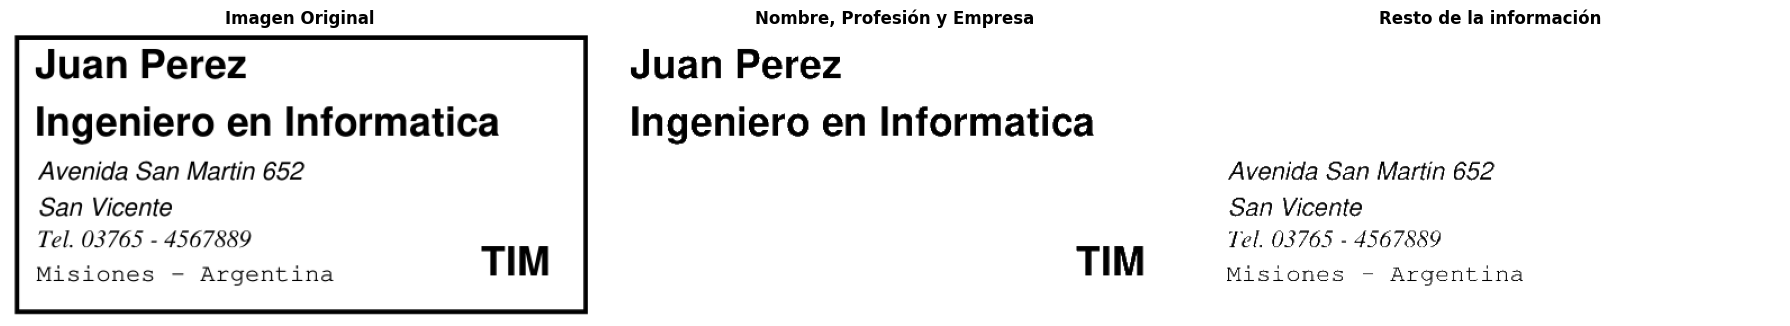

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('tarjeta.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

_, binaria = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Eliminar el marco negro
h_img, w_img = binaria.shape
cv2.rectangle(binaria, (0, 0), (w_img-1, h_img-1), 0, thickness=15)

#Aplicamos dilatacion horizontal para unir las letras de cada palabra en un bloque sólido.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
dilatada = cv2.dilate(binaria, kernel, iterations=1)

contornos, _ = cv2.findContours(dilatada, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

alturas = [cv2.boundingRect(c)[3] for c in contornos if cv2.boundingRect(c)[3] > 5]
max_h = max(alturas) if alturas else 0
umbral_h = max_h * 0.65 

# En lugar de extraer letras enseguida, crearemos una máscara que defina las zonas donde vive el texto principal.
mask_zonas_principales = np.zeros_like(binaria)

for c in contornos:
    x, y, w, h = cv2.boundingRect(c)
    
    if w < 10 or h < 5:
        continue
        
    if h >= umbral_h:
        margen_arriba = int(h * 0.4)
        y_nuevo = max(0, y - margen_arriba) # max(0) evita salirnos de la imagen
        h_nuevo = h + margen_arriba
        cv2.rectangle(mask_zonas_principales, (x, y_nuevo), (x+w, y_nuevo+h_nuevo), 255, -1)

# El texto principal son los píxeles originales que caen DENTRO de las zonas principales
mask_principal = cv2.bitwise_and(binaria, mask_zonas_principales)

# El resto del texto son los píxeles originales que caen FUERA de las zonas principales
mask_resto = cv2.bitwise_and(binaria, cv2.bitwise_not(mask_zonas_principales))

def aplicar_mascara(img_rgb, mask):
    resultado = np.ones_like(img_rgb) * 255
    resultado[mask > 0] = img_rgb[mask > 0]
    return resultado

img_principal = aplicar_mascara(img_rgb, mask_principal)
img_resto_info = aplicar_mascara(img_rgb, mask_resto)

# ════════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN
# ════════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Imagen Original', fontweight='bold')

axes[1].imshow(img_principal)
axes[1].set_title('Nombre, Profesión y Empresa', fontweight='bold')

axes[2].imshow(img_resto_info)
axes[2].set_title('Resto de la información', fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Notas Musicales**

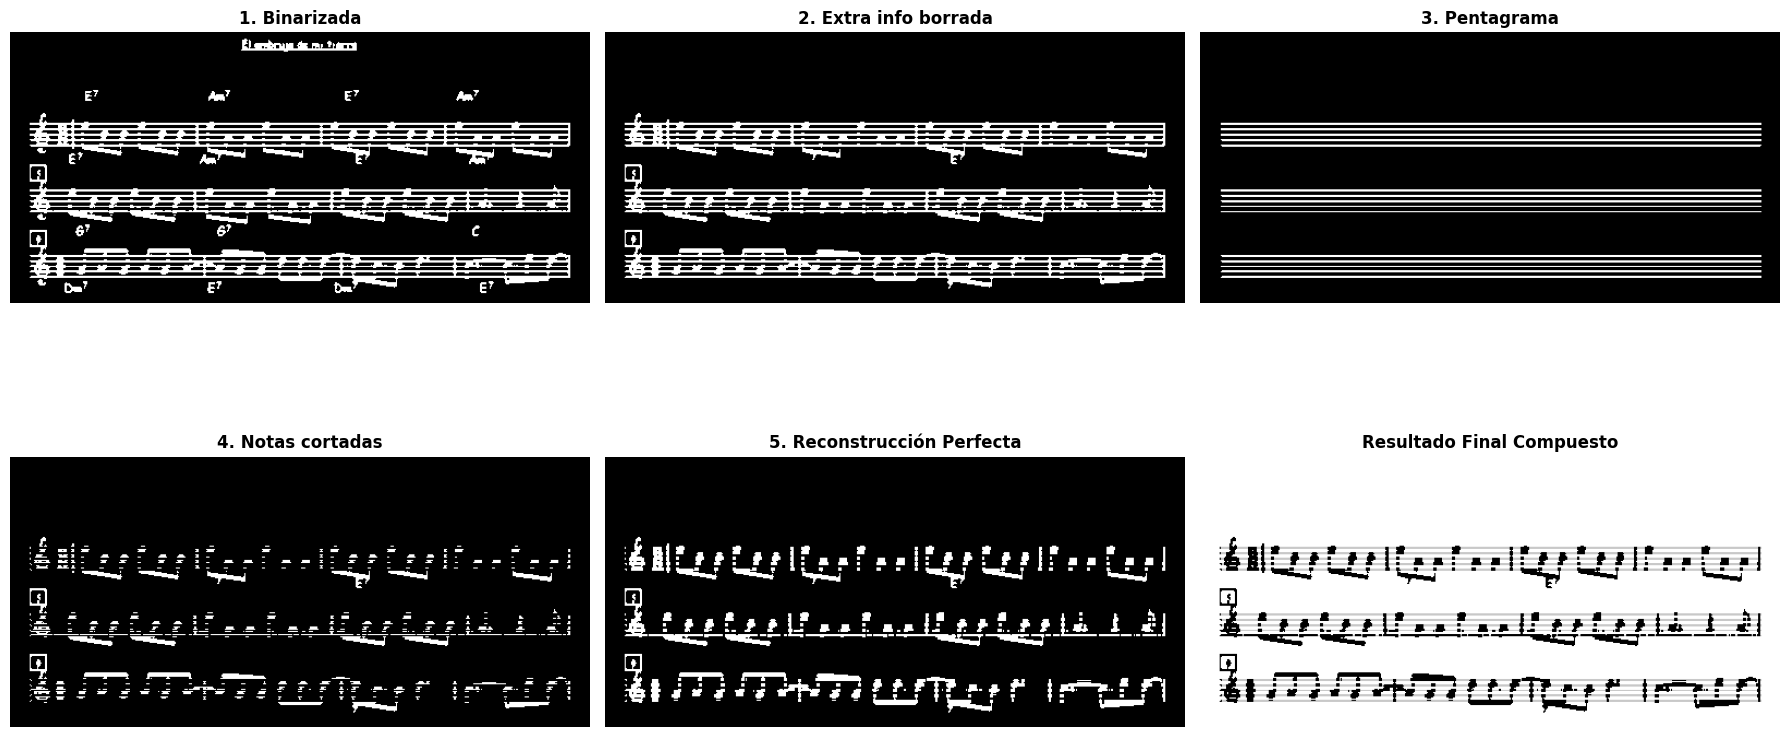

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════════════
# PASO 1: BINARIZAR
# ════════════════════════════════════════════════════════════════════════════════
img = cv2.imread('notas01.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blur = cv2.GaussianBlur(gray, (3, 3), 0)
_, binaria = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# ════════════════════════════════════════════════════════════════════════════════
# PASO 2: DETECTAR Y SACAR ACORDES
# ════════════════════════════════════════════════════════════════════════════════
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binaria)
sin_texto = np.zeros_like(binaria)

for i in range(1, num_labels):
    w = stats[i, cv2.CC_STAT_WIDTH]
    if w > 150:  # Filtramos todo lo que no sea ancho (borra textos y ruido)
        sin_texto[labels == i] = 255

# ════════════════════════════════════════════════════════════════════════════════
# PASO 3: DETECTAR LAS LÍNEAS DEL PENTAGRAMA
# ════════════════════════════════════════════════════════════════════════════════
# Kernel extra largo (200px) para ignorar los corchetes de las notas musicales
kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (200, 1))
lineas = cv2.morphologyEx(sin_texto, cv2.MORPH_OPEN, kernel_h)

# ════════════════════════════════════════════════════════════════════════════════
# PASO 4: BORRAR LAS LÍNEAS (Notas cortadas)
# ════════════════════════════════════════════════════════════════════════════════
# Al restar las notas quedan con cortes
notas_cortadas = cv2.subtract(sin_texto, lineas)

# ════════════════════════════════════════════════════════════════════════════════
# PASO 5: RECONSTRUCCIÓN 
# ════════════════════════════════════════════════════════════════════════════════

kernel_molde = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5))
molde_notas = cv2.dilate(notas_cortadas, kernel_molde)

pedazos_faltantes = cv2.bitwise_and(lineas, molde_notas)

notas_finales = cv2.bitwise_or(notas_cortadas, pedazos_faltantes)

# ════════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN
# ════════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].imshow(binaria, cmap='gray');           
axes[0,0].set_title('1. Binarizada', fontweight='bold')

axes[0,1].imshow(sin_texto, cmap='gray');         
axes[0,1].set_title('2. Extra info borrada', fontweight='bold')

axes[0,2].imshow(lineas, cmap='gray');            
axes[0,2].set_title('3. Pentagrama', fontweight='bold')

axes[1,0].imshow(notas_cortadas, cmap='gray');    
axes[1,0].set_title('4. Notas cortadas', fontweight='bold')

axes[1,1].imshow(notas_finales, cmap='gray'); 
axes[1,1].set_title('5. Reconstrucción Perfecta', fontweight='bold')


resultado_final = np.ones_like(img_rgb) * 255
resultado_final[lineas > 0] = [200, 200, 200]  # Líneas gris claro
resultado_final[notas_finales > 0] = [0, 0, 0] # Notas negras nítidas

axes[1,2].imshow(resultado_final);                
axes[1,2].set_title('Resultado Final Compuesto', fontweight='bold')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

**Globulos Rojos**

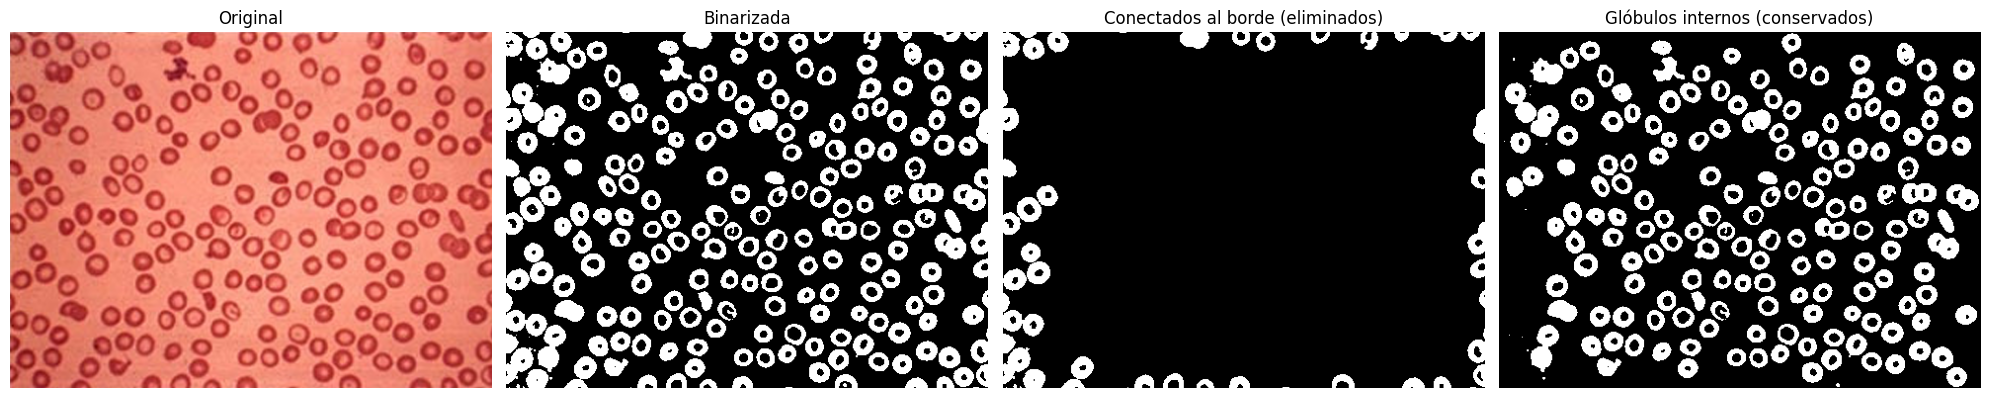

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('globulos.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ── Binarizar ─────────────────────────────────────────────────────────────────
_, binaria = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Marcador = solo los píxeles del borde de la imagen
marcador_borde = np.zeros_like(binaria)
marcador_borde[0, :]  = binaria[0, :]   # fila superior
marcador_borde[-1, :] = binaria[-1, :]  # fila inferior
marcador_borde[:, 0]  = binaria[:, 0]   # columna izquierda
marcador_borde[:, -1] = binaria[:, -1]  # columna derecha

# Reconstrucción por dilatación
def reconstruccion(marcador, mascara):
    kernel = np.ones((3,3), np.uint8)
    prev = np.zeros_like(marcador)
    curr = marcador.copy()
    while cv2.countNonZero(cv2.absdiff(curr, prev)) > 0:
        prev = curr.copy()
        curr = cv2.dilate(curr, kernel)
        curr = cv2.bitwise_and(curr, mascara)
    return curr

# Obtener todo lo conectado al borde
conectado_borde = reconstruccion(marcador_borde, binaria)

# Restar -> quedan solo los glóbulos NO conectados al borde
globulos_internos = cv2.subtract(binaria, conectado_borde)

# ── Visualización ─────────────────────────────────────────────────────────────
resultado_rgb = img_rgb.copy()
resultado_rgb[globulos_internos > 0] = [255, 0, 0]   # rojo = glóbulos internos
resultado_rgb[conectado_borde > 0]   = [100, 100, 100] # gris = eliminados

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_rgb);                    axes[0].set_title('Original')
axes[1].imshow(binaria, cmap='gray');       axes[1].set_title('Binarizada')
axes[2].imshow(conectado_borde, cmap='gray'); axes[2].set_title('Conectados al borde (eliminados)')
axes[3].imshow(globulos_internos, cmap='gray'); axes[3].set_title('Glóbulos internos (conservados)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

**Rio**

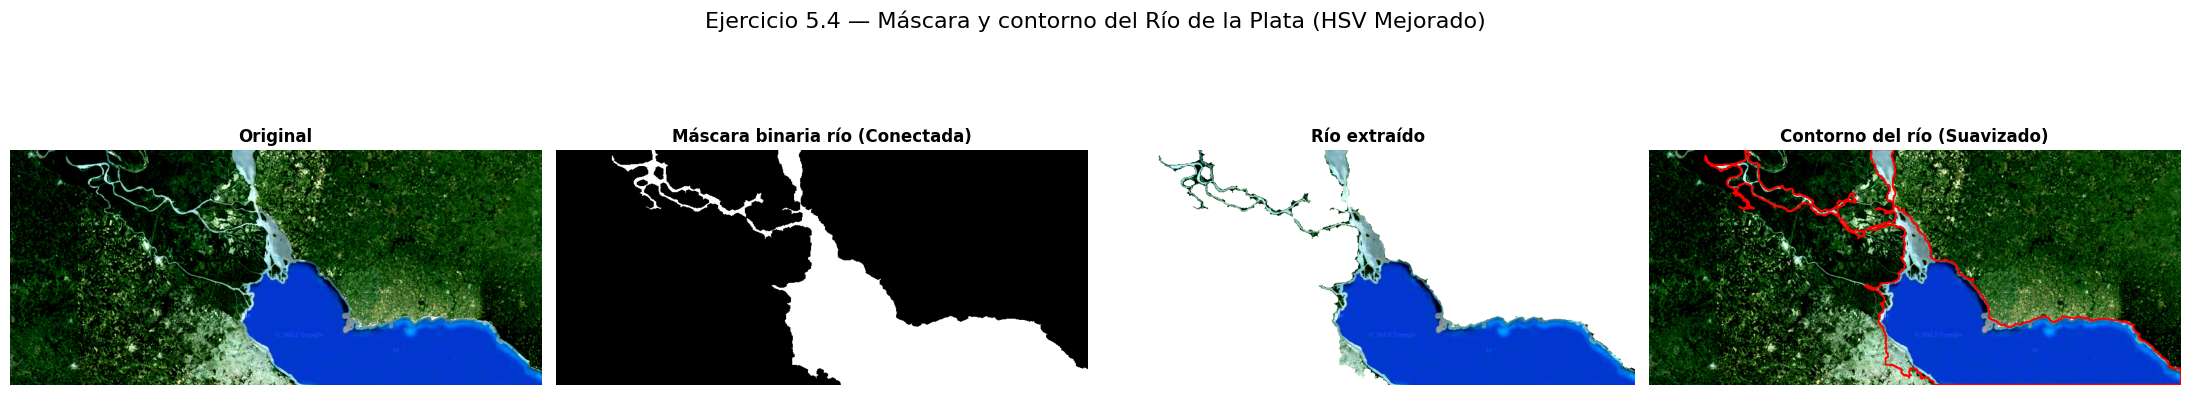

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Rio.png') 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)


# 1. SEGMENTAR POR COLOR
lower_agua = np.array([70,  15,  20])  # Tonos más oscuros y menos saturados
upper_agua = np.array([135, 255, 255])
mascara_agua = cv2.inRange(hsv, lower_agua, upper_agua)

# 2. LIMPIEZA MORFOLÓGICA (Solo Cierre)
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mascara_agua = cv2.morphologyEx(mascara_agua, cv2.MORPH_CLOSE, kernel_close, iterations=2)

# 3. FILTRADO (Río principal + afluentes)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara_agua)

mascara_final = np.zeros_like(mascara_agua)
area_minima = 400 

for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= area_minima:
        mascara_final[labels == i] = 255

# 4. EXTRAER EL RÍO
img_rio = np.ones_like(img_rgb) * 255
img_rio[mascara_final > 0] = img_rgb[mascara_final > 0]

# 5. CONTORNO VECTORIAL
contornos, _ = cv2.findContours(mascara_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contorno = img_rgb.copy()
cv2.drawContours(img_contorno, contornos, -1, (255, 0, 0), thickness=2)

# 6. VISUALIZACIÓN
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original', fontweight='bold')

axes[1].imshow(mascara_final, cmap='gray')
axes[1].set_title('Máscara binaria río (Conectada)', fontweight='bold')

axes[2].imshow(img_rio)
axes[2].set_title('Río extraído', fontweight='bold')

axes[3].imshow(img_contorno)
axes[3].set_title('Contorno del río (Suavizado)', fontweight='bold')

for ax in axes: 
    ax.axis('off')

plt.suptitle('Ejercicio 5.4 — Máscara y contorno del Río de la Plata (HSV Mejorado)', fontsize=16)
plt.tight_layout()
plt.show()

**Melanoma**

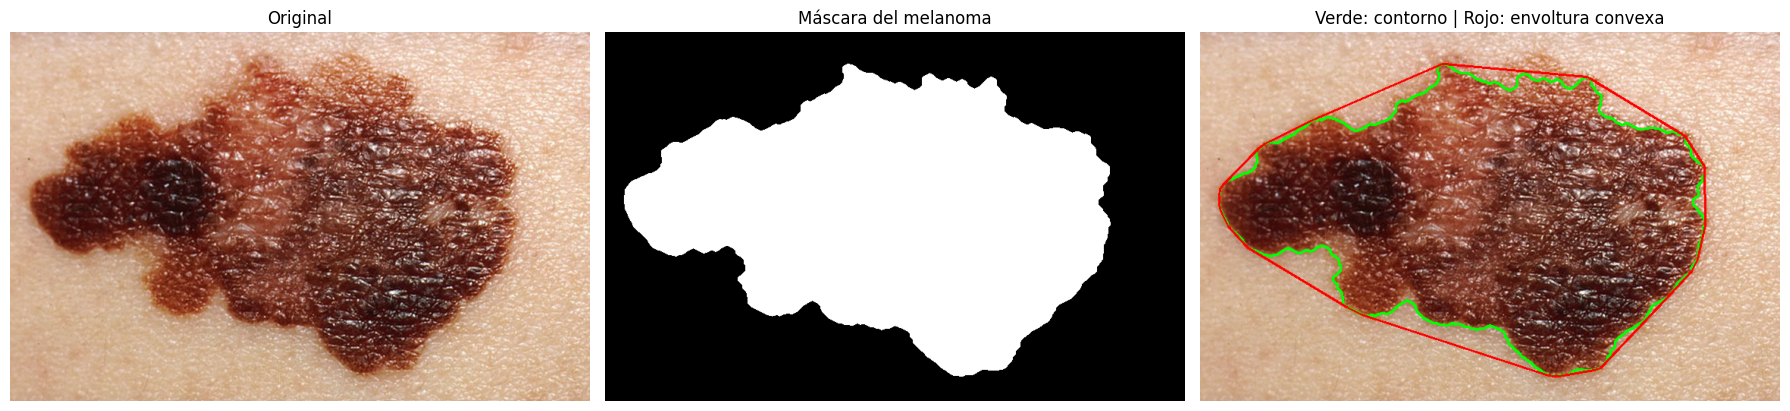

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('melanoma.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ── Binarizar el melanoma ─────────────────────────────────────────────────────
blur = cv2.GaussianBlur(gray, (7,7), 0)
_, binaria = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# ── Limpiar morfológicamente ──────────────────────────────────────────────────
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
binaria = cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, kernel, iterations=3)
binaria = cv2.morphologyEx(binaria, cv2.MORPH_OPEN,  kernel, iterations=2)

# ── Quedarse con el componente más grande (el melanoma) ───────────────────────
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binaria)
idx_max = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
mascara_melanoma = np.uint8(labels == idx_max) * 255

# ── Envoltura convexa con OpenCV ──────────────────────────────────────────────
contornos, _ = cv2.findContours(mascara_melanoma, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_principal = max(contornos, key=cv2.contourArea)
hull = cv2.convexHull(contorno_principal)

# ── Dibujar resultados ────────────────────────────────────────────────────────
img_resultado = img_rgb.copy()
cv2.drawContours(img_resultado, [contorno_principal], -1, (0, 255, 0),  2)  # verde = contorno real
cv2.drawContours(img_resultado, [hull],               -1, (255, 0, 0),  2)  # rojo  = envoltura convexa

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb);                      axes[0].set_title('Original')
axes[1].imshow(mascara_melanoma, cmap='gray'); axes[1].set_title('Máscara del melanoma')
axes[2].imshow(img_resultado)
axes[2].set_title('Verde: contorno | Rojo: envoltura convexa')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

**Cuerpos**

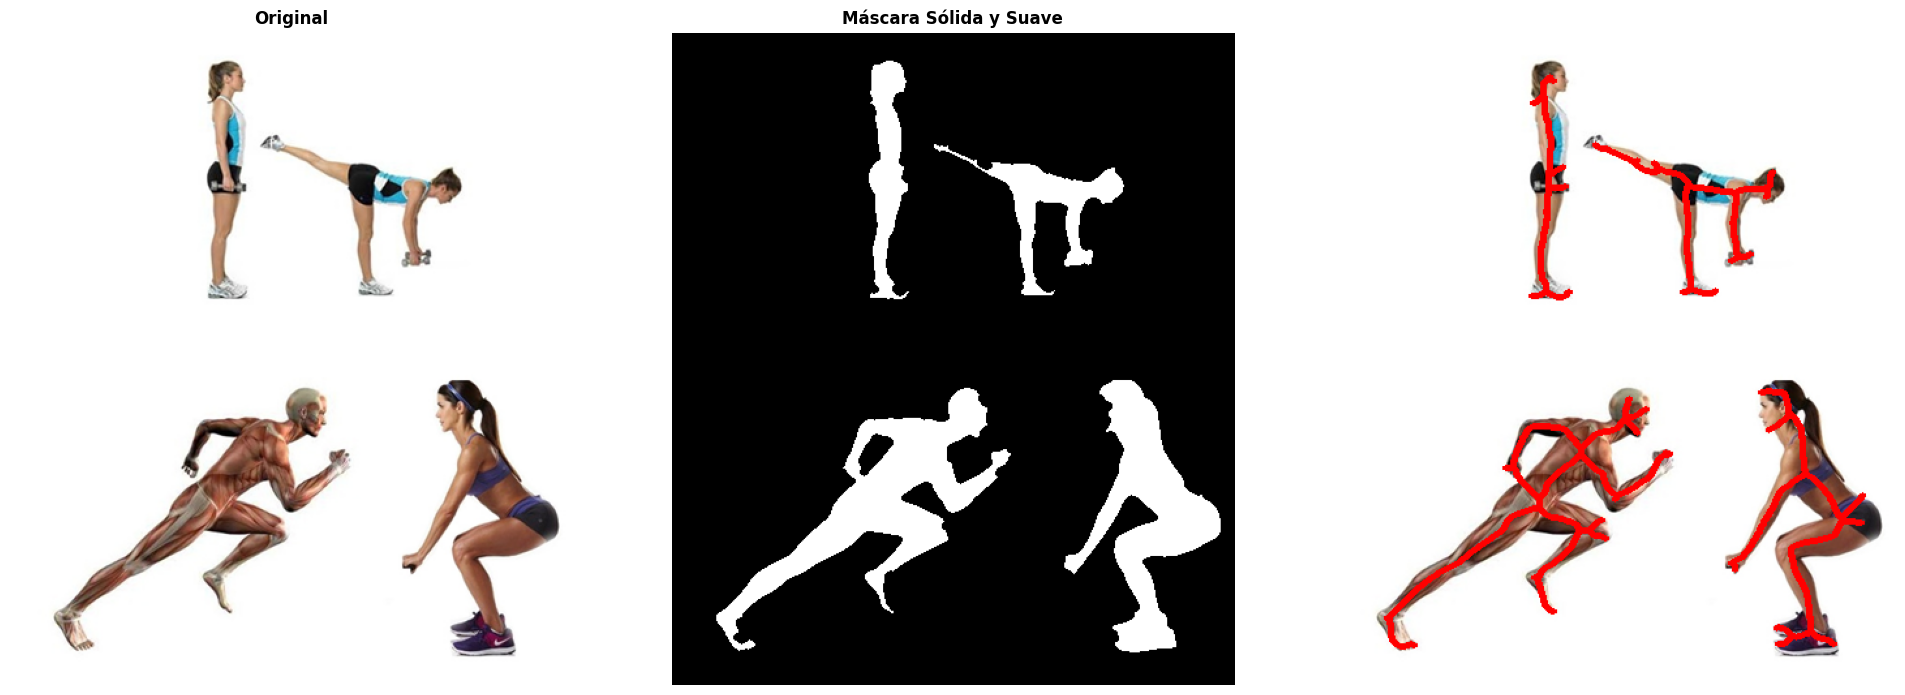

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize


# 1. CARGA Y BINARIZACIÓN
img = cv2.imread('cuerpos.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binaria = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. RELLENADO DE SILUETAS 
contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mascara_solida = np.zeros_like(binaria)

for c in contornos:
    if cv2.contourArea(c) > 500: # Filtramos ruido pequeño
        cv2.drawContours(mascara_solida, [c], -1, 255, thickness=cv2.FILLED)

# 3. SUAVIZADO DE BORDES
kernel_suavizado = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
mascara_suave = cv2.morphologyEx(mascara_solida, cv2.MORPH_CLOSE, kernel_suavizado)

esqueleto_bool = skeletonize(mascara_suave > 0)
esqueleto_fino = (esqueleto_bool * 255).astype(np.uint8)

kernel_esqueleto = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
esqueleto_grueso = cv2.dilate(esqueleto_fino, kernel_esqueleto, iterations=1)

# Creamos la superposición roja usando la máscara ENGROSADA
superpuesta = img_rgb.copy()
superpuesta[esqueleto_grueso > 0] = [255, 0, 0] # Rojo intenso


# 5. VISUALIZACIÓN
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(img_rgb)
axes[0].set_title('Original', fontweight='bold')

axes[1].imshow(mascara_suave, cmap='gray')
axes[1].set_title('Máscara Sólida y Suave', fontweight='bold')

axes[2].imshow(superpuesta)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()